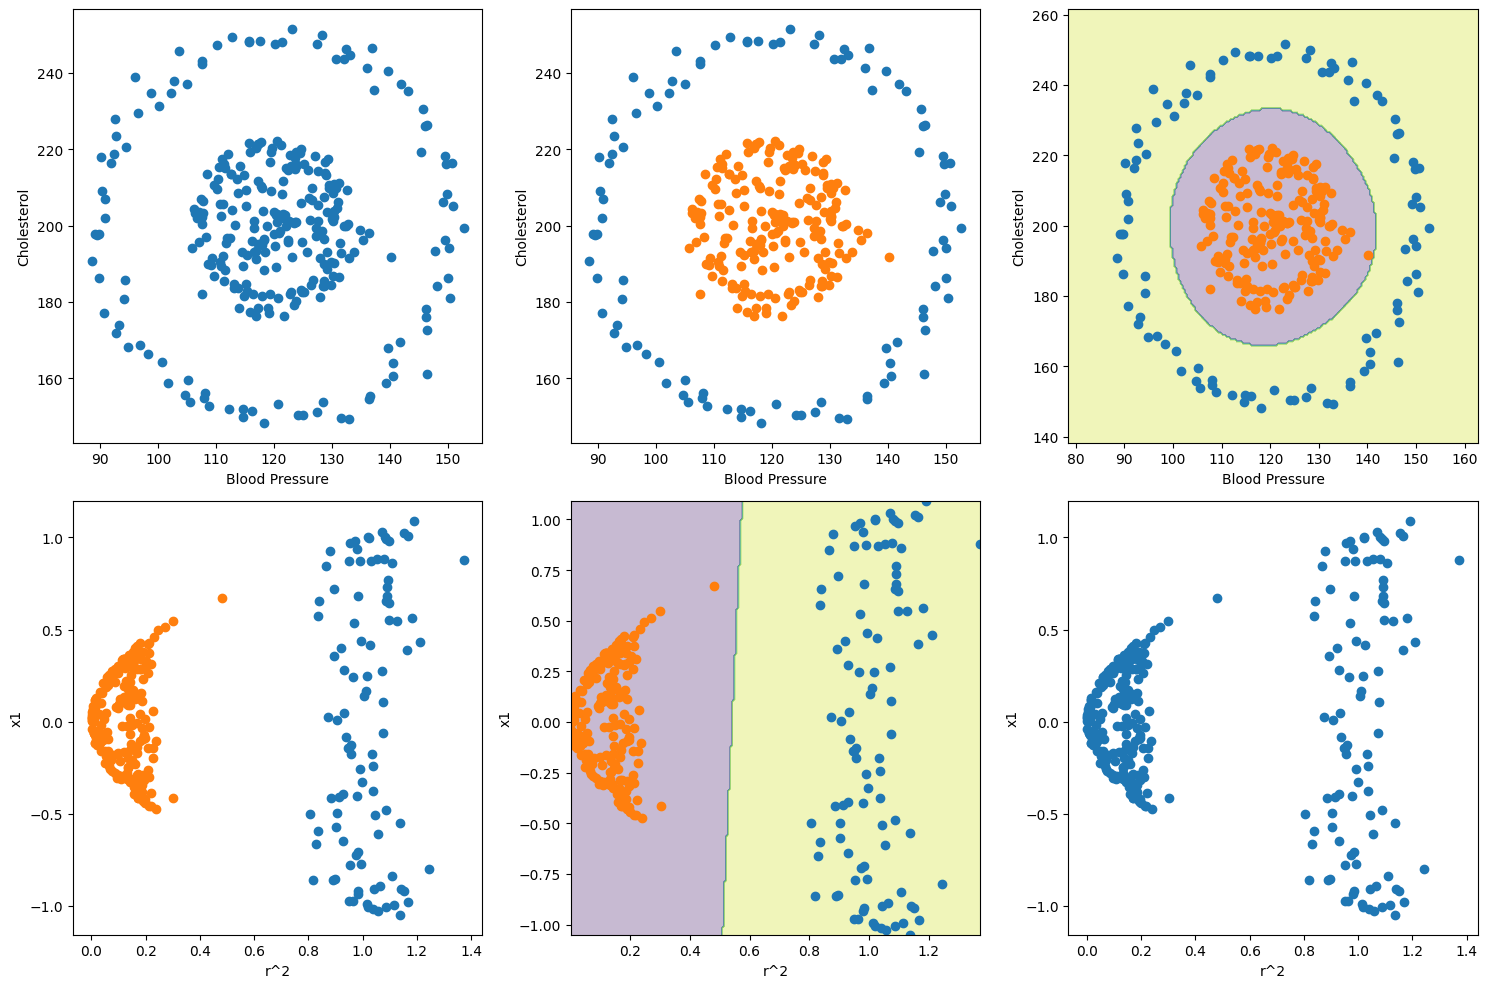

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans
from sklearn.svm import SVC

np.random.seed(32)

# --- Generate data ---
X, _ = make_circles(n_samples=200, factor=0.4, noise=0.05, random_state=50)

n_center = 100
center_points = np.random.normal(loc=0.0, scale=0.2, size=(n_center, 2))

X = np.vstack((X, center_points))


# --- Convert to "real-world" features ---
bp = 120 + 30 * X[:, 0]
chol = 200 + 50 * X[:, 1]


# --- Normalize ---
x1 = (bp - 120) / 30
x2 = (chol - 200) / 50
X_norm = np.column_stack((x1, x2))


# --- Feature transform ---
X_transformed = np.zeros_like(X_norm)
X_transformed[:, 0] = x1**2 + x2**2   # r^2
X_transformed[:, 1] = x1


# --- K-Means on TRANSFORMED space ---
kmeans = KMeans(n_clusters=2)
y_kmeans = kmeans.fit_predict(X_transformed)

# Make cluster with smaller radius = Healthy (1)
if X_transformed[y_kmeans == 0, 0].mean() > X_transformed[y_kmeans == 1, 0].mean():
    y_kmeans = 1 - y_kmeans


# --- Train SVM ---
model_nonlinear = SVC(kernel='rbf')
model_nonlinear.fit(X_norm, y_kmeans)

model_linear = SVC(kernel='linear')
model_linear.fit(X_transformed, y_kmeans)


# --- Plotting ---
fig, axes = plt.subplots(2, 3, figsize=(15, 10))


# ========== (0) Raw Data ==========
ax = axes[0, 0]
ax.scatter(bp, chol)
# ax.set_title("Raw Data (No Labels)")
ax.set_xlabel("Blood Pressure")
ax.set_ylabel("Cholesterol")


# ========== (1) K-Means AFTER Transform ==========
ax = axes[0, 1]
for label_val in [1, 0]:
    ax.scatter(
        bp[y_kmeans == label_val],
        chol[y_kmeans == label_val],
        label='Healthy' if label_val == 1 else 'Risky'
    )

# ax.set_title("K-Means (After Transform)")
ax.set_xlabel("Blood Pressure")
ax.set_ylabel("Cholesterol")


# ========== (2) Nonlinear SVM ==========
ax = axes[0, 2]

xx, yy = np.meshgrid(
    np.linspace(bp.min()-10, bp.max()+10, 200),
    np.linspace(chol.min()-10, chol.max()+10, 200)
)

gx1 = (xx - 120) / 30
gx2 = (yy - 200) / 50
grid = np.column_stack((gx1.ravel(), gx2.ravel()))

Z = model_nonlinear.predict(grid).reshape(xx.shape)

ax.contourf(xx, yy, Z, alpha=0.3)

for label_val in [1, 0]:
    ax.scatter(
        bp[y_kmeans == label_val],
        chol[y_kmeans == label_val],
        label='Healthy' if label_val == 1 else 'Risky'
    )

# ax.set_title("SVM Nonlinear Boundary")
ax.set_xlabel("Blood Pressure")
ax.set_ylabel("Cholesterol")


# ========== (3) Transformed Space ==========
ax = axes[1, 0]

for label_val in [1, 0]:
    ax.scatter(
        X_transformed[y_kmeans == label_val, 0],
        X_transformed[y_kmeans == label_val, 1],
        label='Healthy' if label_val == 1 else 'Risky'
    )

# ax.set_title("Transformed Space (K-Means)")
ax.set_xlabel("r^2")
ax.set_ylabel("x1")


# ========== (4) Linear SVM ==========
ax = axes[1, 1]

z1, z2 = np.meshgrid(
    np.linspace(X_transformed[:,0].min(), X_transformed[:,0].max(), 200),
    np.linspace(X_transformed[:,1].min(), X_transformed[:,1].max(), 200)
)

grid_trans = np.column_stack((z1.ravel(), z2.ravel()))
Z_lin = model_linear.predict(grid_trans).reshape(z1.shape)

ax.contourf(z1, z2, Z_lin, alpha=0.3)

for label_val in [1, 0]:
    ax.scatter(
        X_transformed[y_kmeans == label_val, 0],
        X_transformed[y_kmeans == label_val, 1],
        label='Healthy' if label_val == 1 else 'Risky'
    )

# ax.set_title("Linear SVM (After Transform)")
ax.set_xlabel("r^2")
ax.set_ylabel("x1")




# ========== (1) K-Means AFTER Transform ==========
ax = axes[1, 2]
ax.scatter(X_transformed[:,0], X_transformed[:,1])
# ax.set_title("Raw Data (No Labels)")
ax.set_xlabel("r^2")
ax.set_ylabel("x1")


plt.tight_layout()
plt.show()

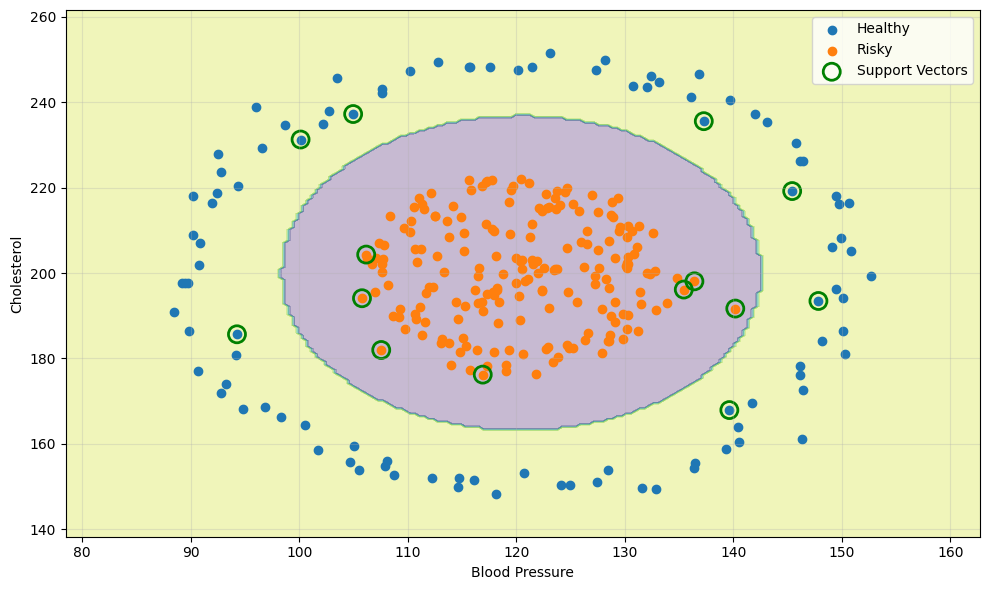

In [7]:
plt.figure(figsize=(10, 6))

# =========================
# GRID DI RUANG ASLI (BP, Chol)
# =========================
xx, yy = np.meshgrid(
    np.linspace(bp.min()-10, bp.max()+10, 200),
    np.linspace(chol.min()-10, chol.max()+10, 200)
)

# =========================
# PIPELINE TRANSFORM
# =========================
# normalize
gx1 = (xx - 120) / 30
gx2 = (yy - 200) / 50

# transform ke (r², x1)
g_r2 = gx1**2 + gx2**2
g_x1 = gx1

grid_trans = np.column_stack((g_r2.ravel(), g_x1.ravel()))

# =========================
# PREDIKSI
# =========================
Z = model_linear.predict(grid_trans)
Z = Z.reshape(xx.shape)

# =========================
# BACKGROUND DECISION REGION
# =========================
plt.contourf(xx, yy, Z, alpha=0.3)

# =========================
# DATA POINTS
# =========================
for label_val in [1, 0]:
    plt.scatter(
        bp[y_kmeans == label_val],
        chol[y_kmeans == label_val],
        label='Healthy' if label_val == 1 else 'Risky'
    )

# =========================
# SUPPORT VECTORS (SAFE VERSION)
# =========================
sv_idx = model_linear.support_

plt.scatter(
    bp[sv_idx],
    chol[sv_idx],
    s=150,
    facecolors='none',
    edgecolors='green',
    linewidth=2,
    label='Support Vectors'
)

# =========================
# FINAL TOUCH
# =========================
plt.xlabel("Blood Pressure")
plt.ylabel("Cholesterol")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

sv nya yg udag ditransformasi balik.

2D ke 3D: yg kita liat di 2D itu sebenernya 3D, diliat dari atas(?)
tergantung data, ada yg bisa ke 2d aja gabisa ke 3d. ada yg bisa ke 3d tapi gabisa ke 2d. 